## Import Libraries

In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Loading Dataset

In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("data/customer_support_tickets.csv")

# Remove missing values
df = df.dropna()

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2769, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
10,11,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,2021-01-19,Cancellation request,Data loss,I'm having an issue with the {product_purchase...,Closed,Measure tonight surface feel forward.,High,Phone,2023-06-01 17:46:49,2023-05-31 23:51:49,1.0
11,12,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,2021-10-24,Product inquiry,Software bug,I'm having an issue with the {product_purchase...,Closed,Measure there house management pick knowledge ...,High,Chat,2023-06-01 12:05:51,2023-06-01 09:27:51,1.0


## Text Cleaning and Preprocessing

In [4]:
# ============================================================
# TEXT CLEANING
# ============================================================

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove stopwords
    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Create cleaned text column
df["clean_text"] = df["Ticket Description"].apply(clean_text)

print("\nFirst 5 Cleaned Tickets:\n")

print(
    df[
        ["Ticket Description", "clean_text"]
    ].head()
)


First 5 Cleaned Tickets:

                                   Ticket Description  \
2   I'm facing a problem with my {product_purchase...   
3   I'm having an issue with the {product_purchase...   
4   I'm having an issue with the {product_purchase...   
10  I'm having an issue with the {product_purchase...   
11  I'm having an issue with the {product_purchase...   

                                           clean_text  
2   im facing problem productpurchased productpurc...  
3   im issue productpurchased please assist proble...  
4   im issue productpurchased please assist note s...  
10  im issue productpurchased please assist produc...  
11  im issue productpurchased please assist possib...  


## Feature Extraction using TF-IDF

In [5]:
# ============================================================
# TF-IDF FEATURE EXTRACTION
# ============================================================

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df["clean_text"]
)

print("Feature Matrix Shape:")
print(X.shape)

Feature Matrix Shape:
(2769, 3610)


## Ticket Type Classification

In [6]:
# ============================================================
# PART 1 : TICKET TYPE CLASSIFICATION
# ============================================================

print("\n===================================")
print("TICKET TYPE CLASSIFICATION")
print("===================================")

y_type = df["Ticket Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_type,
    test_size=0.2,
    random_state=42
)

model_type = MultinomialNB()

model_type.fit(X_train, y_train)

y_pred = model_type.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


TICKET TYPE CLASSIFICATION

Accuracy:
0.21660649819494585

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.31      0.15      0.20       123
Cancellation request       0.12      0.05      0.07        96
     Product inquiry       0.21      0.15      0.17       102
      Refund request       0.20      0.33      0.25       122
     Technical issue       0.22      0.38      0.28       111

            accuracy                           0.22       554
           macro avg       0.21      0.21      0.20       554
        weighted avg       0.22      0.22      0.20       554



## Ticket Type Confusion Matrix

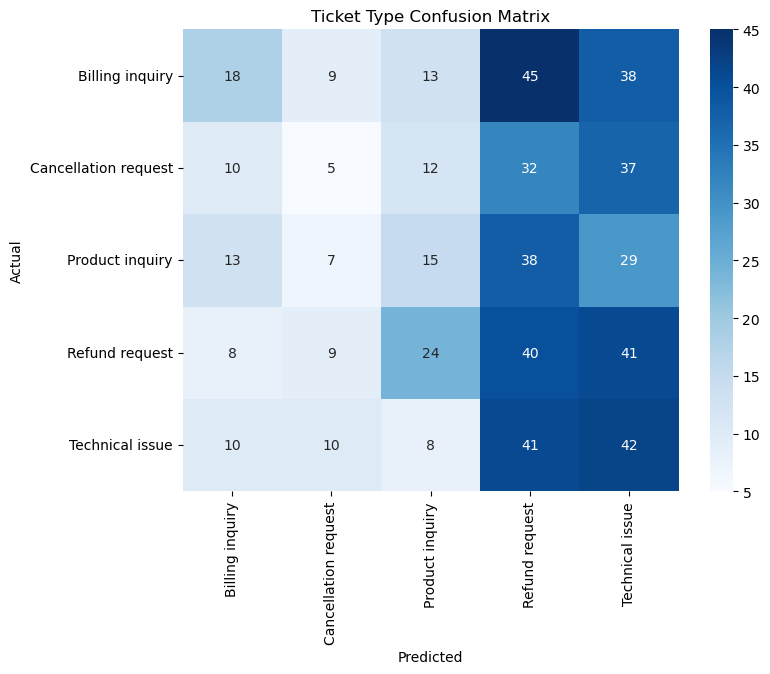

In [7]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model_type.classes_,
    yticklabels=model_type.classes_
)

plt.title("Ticket Type Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Priority Prediction

In [8]:
# ============================================================
# PART 2 : PRIORITY PREDICTION
# ============================================================

print("\n===================================")
print("PRIORITY PREDICTION")
print("===================================")

y_priority = df["Ticket Priority"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

model_priority = MultinomialNB()

model_priority.fit(X_train2, y_train2)

y_pred2 = model_priority.predict(X_test2)

print("\nAccuracy:")
print(accuracy_score(y_test2, y_pred2))

print("\nClassification Report:\n")

print(classification_report(y_test2, y_pred2))


PRIORITY PREDICTION

Accuracy:
0.26173285198555957

Classification Report:

              precision    recall  f1-score   support

    Critical       0.30      0.26      0.28       156
        High       0.21      0.33      0.26       130
         Low       0.29      0.11      0.16       133
      Medium       0.28      0.34      0.30       135

    accuracy                           0.26       554
   macro avg       0.27      0.26      0.25       554
weighted avg       0.27      0.26      0.25       554



## Priority Confusion Matrix

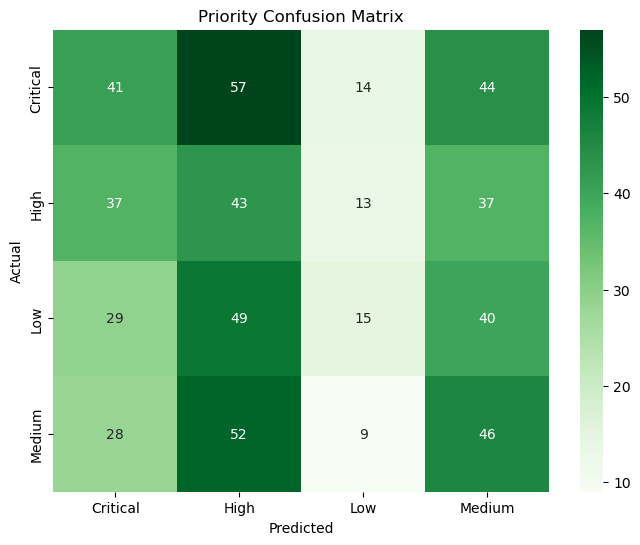

In [9]:
cm2 = confusion_matrix(
    y_test2,
    y_pred2
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=model_priority.classes_,
    yticklabels=model_priority.classes_
)

plt.title("Priority Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Sample Prediction

In [10]:
# ============================================================
# SAMPLE PREDICTION
# ============================================================

print("\n===================================")
print("SAMPLE PREDICTION")
print("===================================")

sample_ticket = [
    "My laptop is overheating and shutting down frequently"
]

sample_vector = vectorizer.transform(
    sample_ticket
)

predicted_type = model_type.predict(
    sample_vector
)

predicted_priority = model_priority.predict(
    sample_vector
)

print("\nTicket:")
print(sample_ticket[0])

print("\nPredicted Category:")
print(predicted_type[0])

print("\nPredicted Priority:")
print(predicted_priority[0])

print("\nProject Completed Successfully!")


SAMPLE PREDICTION

Ticket:
My laptop is overheating and shutting down frequently

Predicted Category:
Cancellation request

Predicted Priority:
Medium

Project Completed Successfully!
